In [1]:
# RANDOM PORCESSES AND MONTE CARLO

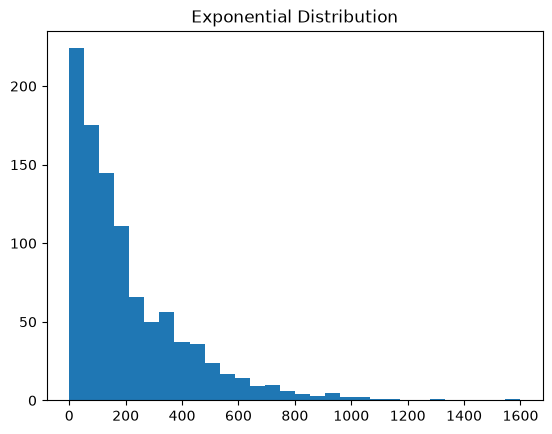

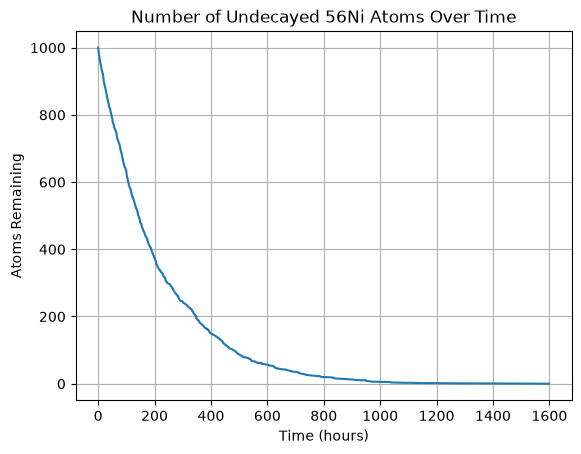

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define parameters
mu = np.log(2)/ (6.075 * 24)

# 2. Initialize the modern random generator
rng = np.random.default_rng()


z_array = rng.random(size=1000)


x = -1 / mu * np.log(1 - z_array)

plt.hist(x, bins=30)
plt.title("Exponential Distribution")
plt.show()

sort_decay = np.sort(x)

# 2. Create the countdown from 1000 down to 0 for your Y-axis using np.arange
atoms_left = np.arange(1000, -1, -1)

# 3. Prepend a 0 to your time array so the plot officially starts at t=0 hours
t_plot = np.insert(sort_decay, 0, 0.0)

# 4. Plot time on X-axis and atoms left on Y-axis
plt.plot(t_plot, atoms_left)
plt.title("Number of Undecayed 56Ni Atoms Over Time")
plt.xlabel("Time (hours)")
plt.ylabel("Atoms Remaining")
plt.grid(True)
plt.show()




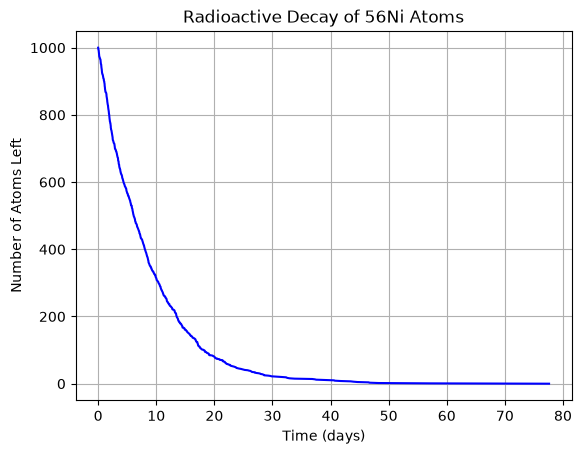

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define physical parameters for Nickel 56
half_life = 6.075                # in days
mu = np.log(2) / half_life       # Decay constant (lambda)

# 2. Initialize random generator
rng = np.random.default_rng()
z_array = rng.random(size=1000)

# 3. Transformation method to get 1000 random decay times
decay_times = -1 / mu * np.log(1 - z_array)

# 4. Sort the decay times chronologically 
sorted_decay_times = np.sort(decay_times)

# 5. Prepend 0 to time so the plot explicitly starts at t=0 days
t_plot = np.insert(sorted_decay_times, 0, 0.0)

# 6. Create the Y-axis array tracking remaining atoms (from 1000 down to 0)
atoms_remaining = np.arange(1000, -1, -1)

# 7. Plot the remaining atoms over time
plt.plot(t_plot, atoms_remaining, color='blue', label='Undecayed Atoms')
plt.xlabel("Time (days)")
plt.ylabel("Number of Atoms Left")
plt.title("Radioactive Decay of 56Ni Atoms")
plt.grid(True)
plt.show()


In [23]:
# Gaussian Random Number Distrubution: RUTHERFORD SCATTERING

import numpy as np

# Constants
Z = 79
e = 1.602e-19
E = 7.7e6*e
epsilon0 = 8.854e-12
a0 = 5.292e-11
sigma = a0/100
N = 1000000

# Function to generate two Gaussian random numbers
rng = np.random.default_rng()
def gaussian(rng):
 r = np.sqrt(-2*sigma*sigma*np.log(1-rng.random()))
 theta = 2*np.pi*rng.random()
 x = r*np.cos(theta)
 y = r*np.sin(theta)
 return x,y
    
# Main program
count = 0
for i in range(N):
    x,y = gaussian(rng)
    b = np.sqrt(x*x+y*y)
    if b<Z*e*e/(2*np.pi*epsilon0*E):
        count += 1
print(count,"particles were reflected out of",N) 

1483 particles were reflected out of 1000000


In [24]:
# MONTE CARLO INTEGRATION: 

import numpy as np

def f(x):
    return (np.sin(1/(x*(2-x))))**2
    
rng = np.random.default_rng()
N = 10000
count = 0
for i in range(N):
    x = 2*rng.random()
    y = rng.random()
    if y<f(x):
        count += 1

I = 2*count/N
print(I)

1.4608


In [39]:
# Monte Carlo: 
import numpy as np

a = 0 
b = 2

def f(x):
    return (np.sin(1/(x*(2-x))))**2
    
rng = np.random.default_rng()
N = 10000
count = 0
for i in range(N):
    x = b*rng.random() # create the box 2 x 1 sample points
    y = rng.random()
    if y<f(x):
        count += 1

# Error of Monte Carlo 
I = 2*count/N
A = 2
# Error
sigma_k = np.sqrt(I*(A-I)/N)


# Mean Value Method: 

x_array = np.random.uniform(0, 2, N)

avg = np.sum(f(x_array))

I_mean = (b-a)/ N * avg

# Error of Mean Monte Carlo:

sigma_prime = b-a/N * np.sqrt(N*np.var(f(x_array)))


print(f"{I_mean} with error {sigma_prime}")


print(f"{I} with error estimate of {sigma_k}")

1.4506600075327294 with error 2.0
1.4416 with error estimate of 0.008972120373690938
